# Learnable Quanvolutional Feature Extractor for CIFAR-10

This notebook replaces the classical CNN feature extractor with a **trainable, patch-based
quantum convolutional layer** ("quanvolution") that feeds directly into your existing
QCNN classifier machinery (encodings, conv/pool blocks, `StronglyEntanglingLayers` readout).

**Honest framing, stated once up front:** there is no established result showing a quantum
feature extractor beats a trained classical CNN on natural images -- that is not the claim
this notebook tests. What it *does* let you measure is: how much accuracy a fully-learnable,
quantum-native local-to-global feature path can recover, compared to your classical-CNN-embedding
pipeline's 0.635 (Pi4Angle, full model) -- using the exact same ablation-style thinking as
Section 17 of the main notebook.

**Compute note:** unlike the classical-CNN front end (fit once, cached), the quantum patches
here are re-encoded through a trainable circuit on *every* forward pass, so this is
computationally heavier per epoch than the main pipeline. Defaults below are scoped down
(smaller sample count, fewer epochs, non-overlapping patches, Z-only readout) to keep a first
run tractable -- see Section 6 for a runtime estimate before you commit to a full run.


## 1. Setup


In [1]:
import os
import time
import warnings
from math import sqrt

import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from torchvision.datasets import CIFAR10
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

try:
    qml.device("lightning.qubit", wires=2)
    QUANTUM_DEVICE_NAME = "lightning.qubit"
except Exception:
    QUANTUM_DEVICE_NAME = "default.qubit"
print("PennyLane version:", qml.__version__)
print("Quantum simulator backend:", QUANTUM_DEVICE_NAME)


PennyLane version: 0.44.1
Quantum simulator backend: lightning.qubit


## 2. Configuration

`SAMPLES_PER_CLASS` and `EPOCHS` default lower than the main notebook -- this pipeline does
`n_patches x n_channels` circuit evaluations per image per forward pass (vs. 1-4 in the main
notebook), so the same sample count would take far longer. Raise them once you have a runtime
estimate from Section 6 you're comfortable with.


In [2]:
CONFIG = dict(
    SAMPLES_PER_CLASS   = 150,
    NUM_CLASSES         = 10,
    TEST_SPLIT          = 0.20,
    VAL_SPLIT           = 0.10,
    RANDOM_SEED         = SEED,

    QUANTUM_DEVICE      = QUANTUM_DEVICE_NAME,
    DIFF_METHOD         = "adjoint",
    CONV_DEPTH          = 1,

    # --- quanvolution layer 1: patch-based, RGB channels, LEARNABLE ---
    QUANV_PATCH_SIZE    = 8,           
    QUANV_QUBITS_PATCH  = 4,           
    QUANV_N_OUT_PATCH   = 2,           
    QUANV_CHANNELS      = ["R", "G", "B"], # Changed to raw RGB
    QUANV_ENCODING      = "Pi4Angle",  
    QUANV_FC_LAYERS     = 1,
    QUANV_MULTI_BASIS   = False,       
    QUANV_POOL_SIZE     = 2,           

    # --- optional quanvolution layer 2 (fusion across channels) ---
    QUANV_NUM_LAYERS    = 2,           # Forced to 2 to enable the high-level feature extraction
    QUANV_FUSION_N_OUT  = 2,

    # --- downstream classifier QCNN ---
    CLASSIFIER_N_QUBITS       = 4,
    CLASSIFIER_ENCODING       = "Pi4Angle",
    N_OUT_QUBITS               = 2,
    FC_LAYERS                  = 1,
    USE_MULTI_BASIS_READOUT    = True,
    RESIDUAL_REUPLOAD_SCALE    = 0.3,

    # --- training ---
    EPOCHS               = 15,         
    BATCH_SIZE            = 32,
    LR                     = 0.02,
    L2_LAMBDA              = 0.006,
    L2_LAMBDA_CIRCUIT      = 0.0005,
    EARLY_STOP_PATIENCE    = 6,
    LR_DECAY_FACTOR        = 0.5,
    LR_DECAY_PATIENCE      = 2,
)
print(CONFIG)

{'SAMPLES_PER_CLASS': 150, 'NUM_CLASSES': 10, 'TEST_SPLIT': 0.2, 'VAL_SPLIT': 0.1, 'RANDOM_SEED': 42, 'QUANTUM_DEVICE': 'lightning.qubit', 'DIFF_METHOD': 'adjoint', 'CONV_DEPTH': 1, 'QUANV_PATCH_SIZE': 8, 'QUANV_QUBITS_PATCH': 4, 'QUANV_N_OUT_PATCH': 2, 'QUANV_CHANNELS': ['R', 'G', 'B'], 'QUANV_ENCODING': 'Pi4Angle', 'QUANV_FC_LAYERS': 1, 'QUANV_MULTI_BASIS': False, 'QUANV_POOL_SIZE': 2, 'QUANV_NUM_LAYERS': 2, 'QUANV_FUSION_N_OUT': 2, 'CLASSIFIER_N_QUBITS': 4, 'CLASSIFIER_ENCODING': 'Pi4Angle', 'N_OUT_QUBITS': 2, 'FC_LAYERS': 1, 'USE_MULTI_BASIS_READOUT': True, 'RESIDUAL_REUPLOAD_SCALE': 0.3, 'EPOCHS': 15, 'BATCH_SIZE': 32, 'LR': 0.02, 'L2_LAMBDA': 0.006, 'L2_LAMBDA_CIRCUIT': 0.0005, 'EARLY_STOP_PATIENCE': 6, 'LR_DECAY_FACTOR': 0.5, 'LR_DECAY_PATIENCE': 2}


## 3. Load CIFAR-10


In [3]:
def load_cifar10_balanced(samples_per_class=500, num_classes=10, seed=42):
    rng = np.random.default_rng(seed)
    try:
        trainset = CIFAR10(root="./data", train=True, download=True)
        testset = CIFAR10(root="./data", train=False, download=True)
        X = np.concatenate([trainset.data, testset.data], axis=0)          # (60000, 32, 32, 3) uint8
        y = np.concatenate([np.array(trainset.targets), np.array(testset.targets)])
        source = "real CIFAR-10"
    except Exception as e:
        print(f"[WARNING] Failed to load CIFAR-10: {e}")
        print("Using synthetic dataset instead (for pipeline smoke-testing only).")
        X = rng.integers(0, 256, size=(num_classes * max(samples_per_class, 50), 32, 32, 3), dtype=np.uint8)
        y = np.repeat(np.arange(num_classes), max(samples_per_class, 50))
        source = "synthetic"

    X_bal, y_bal = [], []
    for cls in range(num_classes):
        idx = np.where(y == cls)[0]
        n_avail = len(idx)
        take = min(samples_per_class, n_avail)
        if take < samples_per_class:
            print(f"[note] class {cls}: only {n_avail} available, using {take}.")
        chosen = rng.choice(idx, size=take, replace=False)
        X_bal.append(X[chosen]); y_bal.append(y[chosen])

    X_bal = np.concatenate(X_bal).astype(np.uint8)
    y_bal = np.concatenate(y_bal).astype(np.int64)

    print("=" * 50)
    print(f"Source      : {source}")
    print(f"Total Images: {len(X_bal)}")
    print(f"Image shape : {X_bal.shape[1:]}")
    print("=" * 50)
    return X_bal, y_bal


CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                    "dog", "frog", "horse", "ship", "truck"]

X_images, y_all = load_cifar10_balanced(CONFIG["SAMPLES_PER_CLASS"], CONFIG["NUM_CLASSES"], CONFIG["RANDOM_SEED"])

X_trainval_img, X_test_img, y_trainval, y_test = train_test_split(
    X_images, y_all, test_size=CONFIG["TEST_SPLIT"], stratify=y_all, random_state=CONFIG["RANDOM_SEED"])
X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_trainval_img, y_trainval, test_size=CONFIG["VAL_SPLIT"], stratify=y_trainval, random_state=CONFIG["RANDOM_SEED"])

print("Train:", X_train_img.shape, " Val:", X_val_img.shape, " Test:", X_test_img.shape)


Files already downloaded and verified
Files already downloaded and verified
Source      : real CIFAR-10
Total Images: 1500
Image shape : (32, 32, 3)
Train: (1080, 32, 32, 3)  Val: (120, 32, 32, 3)  Test: (300, 32, 32, 3)


## 4. Patch + channel-prefilter extraction (classical, fixed, computed once)

This is the only *non-trainable* part of the feature path -- it's plain image processing, not a
learned filter, so (like the CNN embeddings in the main notebook) it's computed once and cached
rather than re-run every epoch. Three channels, each biasing the encoding toward a different
physical property before the quantum circuit ever sees the data (see the earlier discussion of
why generic circuits won't discover edge/texture sensitivity unsupervised on 5,000 images):

- **intensity**: raw grayscale luminance -> flat local brightness
- **edge**: gradient magnitude (finite differences) -> boundaries
- **texture**: local variance -> high-frequency structure

Each 8x8 patch is reduced to `QUANV_QUBITS_PATCH=4` values via 2x2 sub-block averaging (or
variance, for the texture channel), then scaled into `[0, pi]` for angle encoding.


In [4]:
def patchify(arr2d_batch, patch_size, s, reduce="mean"):
    """arr2d_batch: (N, H, W) -> (N, Hp, Wp, s*s) via non-overlapping patch_size tiling,
    each patch reduced to an (s,s) grid via mean or var over (patch_size//s)-sized sub-blocks."""
    N, H, W = arr2d_batch.shape
    Hp, Wp = H // patch_size, W // patch_size
    sub = patch_size // s
    grid = arr2d_batch.reshape(N, Hp, patch_size, Wp, patch_size).transpose(0, 1, 3, 2, 4)   # (N,Hp,Wp,P,P)
    grid = grid.reshape(N, Hp, Wp, s, sub, s, sub)
    if reduce == "mean":
        reduced = grid.mean(axis=(4, 6))
    elif reduce == "var":
        reduced = grid.var(axis=(4, 6))
    else:
        raise ValueError(reduce)
    return reduced.reshape(N, Hp, Wp, s * s), Hp, Wp


def extract_patch_channels(images_uint8, config):
    P = config["QUANV_PATCH_SIZE"]
    nq = config["QUANV_QUBITS_PATCH"]
    s = int(round(np.sqrt(nq)))
    assert s * s == nq, "QUANV_QUBITS_PATCH must be a perfect square (2x2, 3x3, ...)"
    assert 32 % P == 0, "QUANV_PATCH_SIZE must divide 32 evenly"

    # Normalize images to [0, 1] range for RGB
    img_norm = images_uint8.astype(np.float32) / 255.0

    # Extract raw R, G, B channels
    r_feat, Hp, Wp = patchify(img_norm[..., 0], P, s, reduce="mean")
    g_feat, _, _ = patchify(img_norm[..., 1], P, s, reduce="mean")
    b_feat, _, _ = patchify(img_norm[..., 2], P, s, reduce="mean")

    channel_map = {"R": r_feat, "G": g_feat, "B": b_feat}
    channels = []
    
    for name in config["QUANV_CHANNELS"]:
        feat = channel_map[name]
        channels.append(feat * np.pi) # -> [0, pi] for angle encoding

    n_patches = Hp * Wp
    n_channels = len(channels)
    out = np.stack(channels, axis=-1)              
    out = out.reshape(len(images_uint8), n_patches, nq, n_channels).transpose(0, 1, 3, 2) 
    return out, Hp, Wp

t0 = time.time()
X_patches_train, GRID_Hp, GRID_Wp = extract_patch_channels(X_train_img, CONFIG)
X_patches_val, _, _ = extract_patch_channels(X_val_img, CONFIG)
X_patches_test, _, _ = extract_patch_channels(X_test_img, CONFIG)
print(f"RGB Patch extraction done in {time.time() - t0:.1f}s")
print("Patch grid:", GRID_Hp, "x", GRID_Wp, "=", GRID_Hp * GRID_Wp, "patches per image")
print("X_patches_train shape (N, n_patches, n_channels, n_qubits_patch):", X_patches_train.shape)


RGB Patch extraction done in 0.1s
Patch grid: 4 x 4 = 16 patches per image
X_patches_train shape (N, n_patches, n_channels, n_qubits_patch): (1080, 16, 3, 4)


## 5. Encodings and conv/pool circuit blocks (reused from the main notebook, unchanged)

Same `ENCODINGS` dict, `conv_block`/`pool_block`/`qcnn_stack`, and `build_qcnn_circuit` you
already validated in `QCNN_CIFAR10_Hybrid_v7.ipynb` -- reused here both for the per-patch
quanvolution circuits and for the downstream classifier, so this notebook is not introducing new,
untested quantum-circuit code, only a new way of *feeding* these existing pieces.


In [5]:
def enc_pi4angle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for idx, w in enumerate(wires):
        qml.Hadamard(wires=w)
        qml.RY(2 * xr[..., idx], wires=w)


def enc_entangledangle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        qml.RY(xr[..., idx], wires=w)
    for i in range(n - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])


def enc_denseangle(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        qml.RZ(xr[..., idx] ** 2, wires=w)
    for i in range(n):
        for j in range(i + 1, min(i + 3, n)):
            wi, wj = wires[i], wires[j]
            qml.CNOT(wires=[wi, wj])
            qml.RZ(xr[..., i] * xr[..., j], wires=wj)
            qml.CNOT(wires=[wi, wj])


def enc_frqi(x, wires):
    n = len(wires)
    xr = np.clip(np.asarray(x)[..., :n], 0, np.pi)
    for w in wires:
        qml.Hadamard(wires=w)
    for idx, w in enumerate(wires):
        w_next = wires[(idx + 1) % n]
        qml.CRY(2 * xr[..., idx], wires=[w, w_next])


ENCODINGS = {
    "Pi4Angle":        enc_pi4angle,
    "EntangledAngle":  enc_entangledangle,
    "DenseAngle":      enc_denseangle,
    "FRQI":            enc_frqi,
}
print("Loaded", len(ENCODINGS), "encodings for this notebook:", list(ENCODINGS.keys()))


Loaded 4 encodings for this notebook: ['Pi4Angle', 'EntangledAngle', 'DenseAngle', 'FRQI']


In [6]:
CONV_PARAMS = 9   # 2 x U3 (3 params each) + 1 x CRot (3 params)
POOL_PARAMS = 2   # CRX angle, CRZ angle


def conv_block(theta, a, b):
    qml.U3(theta[0], theta[1], theta[2], wires=a)
    qml.U3(theta[3], theta[4], theta[5], wires=b)
    qml.CRot(theta[6], theta[7], theta[8], wires=[a, b])


def pool_block(theta, c, t):
    qml.CRZ(theta[1], wires=[c, t])
    qml.PauliX(wires=c)
    qml.CRX(theta[0], wires=[c, t])
    qml.PauliX(wires=c)


def n_conv_pool_layers(n0, n_out):
    layers, n = 0, n0
    while n > n_out:
        remove = n - n_out
        pairs = min(remove, n // 2)
        n -= pairs
        layers += 1
    return layers


def qcnn_stack(x, wires, conv_weights, pool_weights, n_out, depth_per_layer=1, reupload_scale=0.0):
    current = list(wires)
    n_in = len(wires)
    x_arr = np.asarray(x)
    layer = 0
    while len(current) > n_out:
        n = len(current)
        remove = n - n_out
        pairs = min(remove, n // 2)

        if reupload_scale > 0:
            for i, w in enumerate(current):
                src_idx = i % n_in
                qml.RY(reupload_scale * x_arr[..., src_idx], wires=w)

        for d in range(depth_per_layer):
            cp = conv_weights[layer][d]
            for i in range(n):
                conv_block(cp, current[i], current[(i + 1) % n])

        pp = pool_weights[layer]
        new_current = []
        for i in range(pairs):
            c, t = current[2 * i], current[2 * i + 1]
            pool_block(pp, c, t)
            new_current.append(t)
        new_current.extend(current[2 * pairs:])
        current = new_current
        layer += 1
    return current


def build_qcnn_circuit(encoding_fn, n_qubits, n_out, fc_layers, multi_basis, reupload_scale):
    wires = list(range(n_qubits))
    dev = qml.device(CONFIG["QUANTUM_DEVICE"], wires=n_qubits)
    diff_method = CONFIG.get("DIFF_METHOD", "adjoint") if CONFIG["QUANTUM_DEVICE"] == "lightning.qubit" else "backprop"

    @qml.qnode(dev, diff_method=diff_method)
    def circuit(x, conv_w, pool_w, fc_w):
        encoding_fn(x, wires)
        remaining = qcnn_stack(x, wires, conv_w, pool_w, n_out,
                                depth_per_layer=CONFIG["CONV_DEPTH"], reupload_scale=reupload_scale)
        qml.StronglyEntanglingLayers(fc_w, wires=remaining)
        outs = [qml.expval(qml.PauliZ(w)) for w in remaining]
        if multi_basis:
            outs += [qml.expval(qml.PauliX(w)) for w in remaining]
            outs += [qml.expval(qml.PauliY(w)) for w in remaining]
        return tuple(outs)

    feat_dim = n_out * (3 if multi_basis else 1)
    return circuit, wires, feat_dim


def assemble_features(raw_out, is_batched):
    return pnp.stack(raw_out, axis=-1) if is_batched else pnp.stack(raw_out)


def init_qcnn_weights(n_qubits, n_out, fc_layers, seed=0):
    rng = np.random.default_rng(seed)
    n_layers = n_conv_pool_layers(n_qubits, n_out)
    conv_w = pnp.array(0.1 * rng.standard_normal((max(n_layers, 1), CONFIG["CONV_DEPTH"], CONV_PARAMS)),
                        requires_grad=True)
    pool_w = pnp.array(0.1 * rng.standard_normal((max(n_layers, 1), POOL_PARAMS)), requires_grad=True)
    fc_shape = qml.StronglyEntanglingLayers.shape(n_layers=fc_layers, n_wires=n_out)
    fc_w = pnp.array(0.05 * rng.standard_normal(fc_shape), requires_grad=True)
    return conv_w, pool_w, fc_w


def softmax_cross_entropy_batch(logits, y_onehot):
    m = pnp.max(logits, axis=1, keepdims=True)
    ex = pnp.exp(logits - m)
    p = ex / pnp.sum(ex, axis=1, keepdims=True)
    return -pnp.mean(pnp.sum(y_onehot * pnp.log(p + 1e-9), axis=1))


## 6. The learnable quanvolutional model

Each entry in `self.groups` is a separate small quantum circuit with its own trainable
`(conv_w, pool_w, fc_w)`, built with the exact same `build_qcnn_circuit` used throughout the
main notebook:

- one group per channel in `QUANV_CHANNELS` (intensity / edge / texture), weights **shared
  across all patches** within that channel -- same weight-sharing convention as
  `SHARE_WEIGHTS_ACROSS_CHUNKS` in the main notebook, applied here across spatial positions
  instead of across LDA-feature chunks
- an optional `"fusion"` group (`QUANV_NUM_LAYERS=2`) that mixes the three channels together
  per pooled cell -- this is the second hierarchy level, going from purely local/per-channel
  features to features that combine intensity+edge+texture information
- a final `"classifier"` group -- structurally identical to the main notebook's QCNN classifier

All parameters -- quanvolution weights included -- are optimized **jointly** in a single
`qml.AdamOptimizer` loop, so gradients flow end-to-end from the classification loss back through
the classifier, through the (optional) fusion stage, through the pooling, and into the per-patch
quanvolution circuits. Nothing here is frozen or random.


In [7]:
class QuanvHybridQCNN:
    def __init__(self, config, seed=42):
        self.config = config
        self.channel_names = list(config["QUANV_CHANNELS"])
        self.n_layers = config["QUANV_NUM_LAYERS"]
        assert self.n_layers in (1, 2)

        # groups, in flat-parameter order
        self.groups = list(self.channel_names)
        if self.n_layers == 2:
            self.groups.append("fusion")
        self.groups.append("classifier")

        self.circuits, self.wires, self.feat_dims = {}, {}, {}
        nq_patch, nout_patch = config["QUANV_QUBITS_PATCH"], config["QUANV_N_OUT_PATCH"]
        enc_patch = ENCODINGS[config["QUANV_ENCODING"]]
        
        for name in self.channel_names:
            c, w, fd = build_qcnn_circuit(enc_patch, nq_patch, nout_patch,
                                           config["QUANV_FC_LAYERS"], config["QUANV_MULTI_BASIS"], 0.0)
            self.circuits[name], self.wires[name], self.feat_dims[name] = c, w, fd

        self.layer1_feat_dim = sum(self.feat_dims[n] for n in self.channel_names) 

        if self.n_layers == 2:
            nq_fusion = self.layer1_feat_dim
            c, w, fd = build_qcnn_circuit(enc_patch, nq_fusion, config["QUANV_FUSION_N_OUT"],
                                           config["QUANV_FC_LAYERS"], config["QUANV_MULTI_BASIS"], 0.0)
            self.circuits["fusion"], self.wires["fusion"], self.feat_dims["fusion"] = c, w, fd

        pooled_cells_1 = (GRID_Hp // config["QUANV_POOL_SIZE"]) * (GRID_Wp // config["QUANV_POOL_SIZE"])
        
        # --- SKIP CONNECTION ARCHITECTURE UPDATE ---
        # We aggregate BOTH Layer 1 (low-level) and Layer 2 (high-level) features for the classifier
        if self.n_layers == 1:
            self.embed_dim = pooled_cells_1 * self.layer1_feat_dim
            self.skip_dim = self.layer1_feat_dim         
        else:
            pooled_cells_2 = pooled_cells_1 // (config["QUANV_POOL_SIZE"] ** 2) or 1
            # Combine low-level pooled dimensions and high-level fused dimensions
            self.embed_dim = (pooled_cells_2 * self.feat_dims["fusion"]) + (pooled_cells_1 * self.layer1_feat_dim)
            self.skip_dim = self.feat_dims["fusion"] + self.layer1_feat_dim

        enc_clf = ENCODINGS[config["CLASSIFIER_ENCODING"]]
        nq_clf = config["CLASSIFIER_N_QUBITS"]
        c, w, fd = build_qcnn_circuit(enc_clf, nq_clf, config["N_OUT_QUBITS"], config["FC_LAYERS"],
                                       config["USE_MULTI_BASIS_READOUT"], config["RESIDUAL_REUPLOAD_SCALE"])
        self.circuits["classifier"], self.wires["classifier"], self.feat_dims["classifier"] = c, w, fd
        self.n_clf_chunks = int(np.ceil(self.embed_dim / nq_clf))
        self.nq_clf = nq_clf

        rng = np.random.default_rng(seed)
        self.conv_w, self.pool_w, self.fc_w = [], [], []
        for i, name in enumerate(self.groups):
            nq = nq_clf if name == "classifier" else (
                 nq_patch if name in self.channel_names else self.layer1_feat_dim)
            nout = (config["N_OUT_QUBITS"] if name == "classifier" else
                    config["QUANV_FUSION_N_OUT"] if name == "fusion" else nout_patch)
            fcl = config["FC_LAYERS"] if name == "classifier" else config["QUANV_FC_LAYERS"]
            cw, pw, fw = init_qcnn_weights(nq, nout, fcl, seed=seed + i)
            self.conv_w.append(cw); self.pool_w.append(pw); self.fc_w.append(fw)

        clf_feat_total = self.n_clf_chunks * self.feat_dims["classifier"] + self.skip_dim
        self.W = pnp.array(0.1 * rng.standard_normal((clf_feat_total, config["NUM_CLASSES"])), requires_grad=True)
        self.b = pnp.array(np.zeros(config["NUM_CLASSES"]), requires_grad=True)

    def all_params(self):
        return (*self.conv_w, *self.pool_w, *self.fc_w, self.W, self.b)

    def set_params(self, flat):
        nG = len(self.groups)
        self.conv_w = list(flat[0:nG])
        self.pool_w = list(flat[nG:2 * nG])
        self.fc_w = list(flat[2 * nG:3 * nG])
        self.W, self.b = flat[3 * nG], flat[3 * nG + 1]

    @staticmethod
    def _to_encoding_range(feat):
        return (feat + 1.0) * (np.pi / 2.0)

    def forward_batch(self, X_patches_batch, conv_w, pool_w, fc_w, W, b):
        batch, n_patches, n_channels, nq = X_patches_batch.shape
        gi = {name: i for i, name in enumerate(self.groups)}

        layer1_outs = []
        for name in self.channel_names:
            i = gi[name]
            flat_patches = X_patches_batch[:, :, self.channel_names.index(name), :].reshape(batch * n_patches, nq)
            raw = self.circuits[name](flat_patches, conv_w[i], pool_w[i], fc_w[i])
            feats = assemble_features(raw, is_batched=True).reshape(batch, n_patches, self.feat_dims[name])
            layer1_outs.append(feats)
        layer1 = pnp.concatenate(layer1_outs, axis=-1)                       

        p = self.config["QUANV_POOL_SIZE"]
        Hp2, Wp2 = GRID_Hp // p, GRID_Wp // p
        grid = layer1.reshape(batch, GRID_Hp, GRID_Wp, self.layer1_feat_dim)
        pooled = grid.reshape(batch, Hp2, p, Wp2, p, self.layer1_feat_dim).mean(axis=(2, 4))
        pooled = pooled.reshape(batch, Hp2 * Wp2, self.layer1_feat_dim)      
        
        # Low-level skip feature (global mean of early layer)
        skip_low = pnp.mean(pooled, axis=1)                                      

        if self.n_layers == 2:
            i = gi["fusion"]
            fusion_in = self._to_encoding_range(pooled).reshape(batch * Hp2 * Wp2, self.layer1_feat_dim)
            raw = self.circuits["fusion"](fusion_in, conv_w[i], pool_w[i], fc_w[i])
            fused = assemble_features(raw, is_batched=True).reshape(batch, Hp2 * Wp2, self.feat_dims["fusion"])
            
            p2 = self.config["QUANV_POOL_SIZE"]
            Hp3, Wp3 = max(Hp2 // p2, 1), max(Wp2 // p2, 1)
            
            if Hp3 * Wp3 < Hp2 * Wp2:
                grid2 = fused.reshape(batch, Hp2, Wp2, self.feat_dims["fusion"])
                embed_fused = grid2.reshape(batch, Hp3, p2, Wp3, p2, self.feat_dims["fusion"]).mean(axis=(2, 4))
                embed_fused = embed_fused.reshape(batch, Hp3 * Wp3 * self.feat_dims["fusion"])
            else:
                embed_fused = fused.reshape(batch, Hp2 * Wp2 * self.feat_dims["fusion"])
                
            skip_high = pnp.mean(fused, axis=1)
            
            # Feature Pyramid Aggregation: Combine low-level pooled and high-level fused embeddings
            embed_pooled = pooled.reshape(batch, Hp2 * Wp2 * self.layer1_feat_dim)
            embed = pnp.concatenate([embed_pooled, embed_fused], axis=1)
            
            # Combine both skip representations
            skip = pnp.concatenate([skip_low, skip_high], axis=1)
            
        else:
            embed = pooled.reshape(batch, Hp2 * Wp2 * self.layer1_feat_dim)
            skip = skip_low

        embed = self._to_encoding_range(embed)
        pad = self.n_clf_chunks * self.nq_clf - embed.shape[1]
        
        if pad > 0:
            embed = pnp.concatenate([embed, pnp.zeros((batch, pad))], axis=1)
        
        embed_chunks = embed.reshape(batch, self.n_clf_chunks, self.nq_clf)

        i = gi["classifier"]
        clf_feats = []
        for c in range(self.n_clf_chunks):
            raw = self.circuits["classifier"](embed_chunks[:, c, :], conv_w[i], pool_w[i], fc_w[i])
            clf_feats.append(assemble_features(raw, is_batched=True))
            
        clf_feats.append(skip)
        feats = pnp.concatenate(clf_feats, axis=1)
        return feats @ W + b

    def predict_proba_numpy(self, X_patches_batch, batch_size=32):
        outs = []
        for start in range(0, len(X_patches_batch), batch_size):
            xb = X_patches_batch[start:start + batch_size]
            logits = self.forward_batch(xb, self.conv_w, self.pool_w, self.fc_w, self.W, self.b)
            logits = np.array(logits)
            ex = np.exp(logits - logits.max(axis=1, keepdims=True))
            outs.append(ex / ex.sum(axis=1, keepdims=True))
        return np.concatenate(outs, axis=0)

    def predict(self, X_patches_batch, batch_size=32):
        return np.argmax(self.predict_proba_numpy(X_patches_batch, batch_size), axis=1)

print("QuanvHybridQCNN Feature Pyramid Architecture defined.")

QuanvHybridQCNN Feature Pyramid Architecture defined.


## 7. Training loop (joint optimization over quanvolution + classifier weights)

Same structure as `train_hybrid_qcnn` in the main notebook -- Adam, reduce-LR-on-plateau,
best-val checkpointing, early stopping -- generalized to loop over however many parameter
groups the model has (3 channels, +1 fusion if enabled, +1 classifier) instead of a fixed
`nF`-filter count.


In [8]:
def train_quanv_hybrid_qcnn(model, X_train_patches, y_train_onehot, X_val_patches, y_val,
                            epochs, batch_size, lr, verbose=True,
                            l2_lambda=0.006, l2_lambda_circuit=0.0005, patience=6,
                            lr_decay_factor=0.5, lr_decay_patience=2):
    opt = qml.AdamOptimizer(stepsize=lr)
    n = len(X_train_patches)
    rng = np.random.default_rng(0)
    nG = len(model.groups)

    def cost(*flat_params, Xb, Yb):
        conv_w, pool_w, fc_w = flat_params[0:nG], flat_params[nG:2 * nG], flat_params[2 * nG:3 * nG]
        W, b = flat_params[3 * nG], flat_params[3 * nG + 1]
        logits = model.forward_batch(Xb, conv_w, pool_w, fc_w, W, b)
        ce_loss = softmax_cross_entropy_batch(logits, Yb)

        l2 = pnp.sum(W ** 2) + pnp.sum(b ** 2)
        for fw in fc_w:
            l2 = l2 + pnp.sum(fw ** 2)
        l2_circuit = 0.0
        for cw in conv_w:
            l2_circuit = l2_circuit + pnp.sum(cw ** 2)
        for pw in pool_w:
            l2_circuit = l2_circuit + pnp.sum(pw ** 2)

        return ce_loss + l2_lambda * l2 + l2_lambda_circuit * l2_circuit

    params = list(model.all_params())
    history = {"epoch": [], "train_loss": [], "train_acc": [], "val_acc": [], "lr": [], "best_val_acc": None}

    best_val_acc = -1.0
    best_params = None
    epochs_no_improve, epochs_since_decay, n_decays = 0, 0, 0

    for epoch in range(epochs):
        perm = rng.permutation(n)
        epoch_loss, n_batches = 0.0, 0
        train_correct, train_seen = 0, 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xb, Yb = X_train_patches[idx], y_train_onehot[idx]
            new_params = opt.step(lambda *p: cost(*p, Xb=Xb, Yb=Yb), *params)
            params = list(new_params)
            batch_loss = float(cost(*params, Xb=Xb, Yb=Yb))
            epoch_loss += batch_loss
            n_batches += 1

            conv_w, pool_w, fc_w = params[0:nG], params[nG:2 * nG], params[2 * nG:3 * nG]
            W, b = params[3 * nG], params[3 * nG + 1]
            logits = model.forward_batch(Xb, conv_w, pool_w, fc_w, W, b)
            preds = np.argmax(np.array(logits), axis=1)
            train_correct += int((preds == y_train[idx]).sum())
            train_seen += len(idx)

        model.set_params(params)
        train_acc = train_correct / max(train_seen, 1)
        val_acc = accuracy_score(y_val, model.predict(X_val_patches))
        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss / max(n_batches, 1))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(opt.stepsize)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_params = [np.array(p) if not isinstance(p, np.ndarray) else p.copy() for p in params]
            epochs_no_improve = 0
            epochs_since_decay = 0
        else:
            epochs_no_improve += 1
            epochs_since_decay += 1

        if verbose:
            marker = "  <-- best so far" if is_best else ""
            print(f"    epoch {epoch + 1:2d}/{epochs} | lr={opt.stepsize:.4f} | "
                  f"loss={history['train_loss'][-1]:.4f} | train acc={train_acc:.3f} | val acc={val_acc:.3f}{marker}")

        if lr_decay_factor and epochs_no_improve >= lr_decay_patience:
            opt.stepsize *= lr_decay_factor
            n_decays += 1
            epochs_no_improve = 0
            if verbose:
                print(f"    no improvement for {lr_decay_patience} epochs -- decaying lr to {opt.stepsize:.4f} (decay #{n_decays})")

        if patience and epochs_since_decay >= patience:
            if verbose:
                print(f"    early stopping (no val improvement in {patience} epochs even after {n_decays} lr decay(s))")
            break

    if best_params is not None:
        model.set_params(best_params)
    history["best_val_acc"] = best_val_acc
    return history


print("train_quanv_hybrid_qcnn defined.")


train_quanv_hybrid_qcnn defined.


## 8. Runtime estimate -- check this before launching a full run

Total circuit evaluations for training scale as:
`epochs x ceil(n_train/batch_size) x (n_patches x n_channels [+ fusion cells] + n_clf_chunks)`.
This is your safety check -- the main notebook's ablation cell showed ~7,000-7,600s for a *single*
config with only 1-4 circuit calls per sample; this pipeline makes many more calls per sample, so
sanity-check the estimate below before committing CPU time.


In [9]:
def estimate_quanv_cost(model, n_train, config):
    calls_per_sample = len(model.channel_names)                      # layer 1: one call per channel (patches batched together per circuit call, but cost scales with n_patches too)
    calls_per_sample *= GRID_Hp * GRID_Wp                             # each channel circuit is called once per patch position (flattened into the batch dim)
    if model.n_layers == 2:
        p = config["QUANV_POOL_SIZE"]
        calls_per_sample += (GRID_Hp // p) * (GRID_Wp // p)           # fusion circuit, once per pooled cell
    calls_per_sample += model.n_clf_chunks                            # classifier circuit, once per chunk

    n_batches_per_epoch = int(np.ceil(n_train / config["BATCH_SIZE"]))
    total_calls_per_epoch = calls_per_sample * n_train                # circuits are batched, but cost still scales with total (sample x call) pairs
    total_calls_all_epochs = total_calls_per_epoch * config["EPOCHS"]

    # rough throughput anchor from the main notebook's ablation run: ~7,300s for a config with
    # ~1 circuit-call-equivalent per sample per epoch at similar qubit counts (2-4 qubits) -- use
    # that as a per-(sample x call) time budget estimate.
    anchor_seconds_per_epoch_per_call = 7300 / max(n_batches_per_epoch * config["BATCH_SIZE"], 1)
    est_seconds = total_calls_all_epochs * anchor_seconds_per_epoch_per_call

    print(f"Circuit calls per sample per forward pass : {calls_per_sample}")
    print(f"Total (sample x call) evaluations, full run : {total_calls_all_epochs:,}")
    print(f"Very rough wall-clock estimate               : {est_seconds/3600:.1f} hours "
          f"(anchored to the main notebook's per-call throughput -- treat as order-of-magnitude only)")
    print()
    print("If this is too high: lower SAMPLES_PER_CLASS, EPOCHS, QUANV_PATCH_SIZE (fewer/larger "
          "patches), or drop a channel from QUANV_CHANNELS before running Section 9.")
    return est_seconds


model_probe = QuanvHybridQCNN(CONFIG, seed=CONFIG["RANDOM_SEED"])
_ = estimate_quanv_cost(model_probe, len(X_train_img), CONFIG)
print("\nEmbedding dim feeding the classifier:", model_probe.embed_dim, "-> ", model_probe.n_clf_chunks, "classifier chunks")


Circuit calls per sample per forward pass : 59
Total (sample x call) evaluations, full run : 955,800
Very rough wall-clock estimate               : 1781.4 hours (anchored to the main notebook's per-call throughput -- treat as order-of-magnitude only)

If this is too high: lower SAMPLES_PER_CLASS, EPOCHS, QUANV_PATCH_SIZE (fewer/larger patches), or drop a channel from QUANV_CHANNELS before running Section 9.

Embedding dim feeding the classifier: 26 ->  7 classifier chunks


## 9. Train


In [10]:
y_train_onehot = np.eye(CONFIG["NUM_CLASSES"])[y_train]

quanv_model = QuanvHybridQCNN(CONFIG, seed=CONFIG["RANDOM_SEED"])
print(f"Model groups (flat-param order): {quanv_model.groups}")
print(f"Embedding dim -> classifier: {quanv_model.embed_dim} ({quanv_model.n_clf_chunks} chunks of {quanv_model.nq_clf} qubits)")

t0 = time.time()
quanv_history = train_quanv_hybrid_qcnn(
    quanv_model, X_patches_train, y_train_onehot, X_patches_val, y_val,
    epochs=CONFIG["EPOCHS"], batch_size=CONFIG["BATCH_SIZE"], lr=CONFIG["LR"], verbose=True,
    l2_lambda=CONFIG["L2_LAMBDA"], l2_lambda_circuit=CONFIG["L2_LAMBDA_CIRCUIT"],
    patience=CONFIG["EARLY_STOP_PATIENCE"], lr_decay_factor=CONFIG["LR_DECAY_FACTOR"],
    lr_decay_patience=CONFIG["LR_DECAY_PATIENCE"])
best_va = quanv_history["best_val_acc"]
print(f"\nTraining finished in {time.time() - t0:.1f}s. Best val acc: {best_va:.3f}")


Model groups (flat-param order): ['R', 'G', 'B', 'fusion', 'classifier']
Embedding dim -> classifier: 26 (7 chunks of 4 qubits)
    epoch  1/15 | lr=0.0200 | loss=2.2556 | train acc=0.181 | val acc=0.200  <-- best so far
    epoch  2/15 | lr=0.0200 | loss=2.1474 | train acc=0.238 | val acc=0.242  <-- best so far
    epoch  3/15 | lr=0.0200 | loss=2.1106 | train acc=0.248 | val acc=0.242
    epoch  4/15 | lr=0.0200 | loss=2.0982 | train acc=0.283 | val acc=0.250  <-- best so far
    epoch  5/15 | lr=0.0200 | loss=2.0845 | train acc=0.269 | val acc=0.200
    epoch  6/15 | lr=0.0200 | loss=2.0757 | train acc=0.290 | val acc=0.242
    no improvement for 2 epochs -- decaying lr to 0.0100 (decay #1)
    epoch  7/15 | lr=0.0100 | loss=2.0574 | train acc=0.289 | val acc=0.233
    epoch  8/15 | lr=0.0100 | loss=2.0539 | train acc=0.286 | val acc=0.225
    no improvement for 2 epochs -- decaying lr to 0.0050 (decay #2)
    epoch  9/15 | lr=0.0050 | loss=2.0458 | train acc=0.303 | val acc=0.242
 

## 10. Evaluate on test set, compare to the classical-CNN pipeline

`REFERENCE_CNN_ACC` below is the main notebook's full-model Pi4Angle test accuracy on
`SAMPLES_PER_CLASS=500` -- not a like-for-like comparison at your (likely smaller)
`SAMPLES_PER_CLASS` here, but a useful anchor. For a fair comparison, also run the main
notebook's classical-CNN pipeline at the *same* `SAMPLES_PER_CLASS` you used here.


Learnable quanvolution + QCNN classifier -- test accuracy: 0.217
Chance level                                              : 0.100
Classical-CNN pipeline reference (different sample count) : 0.635


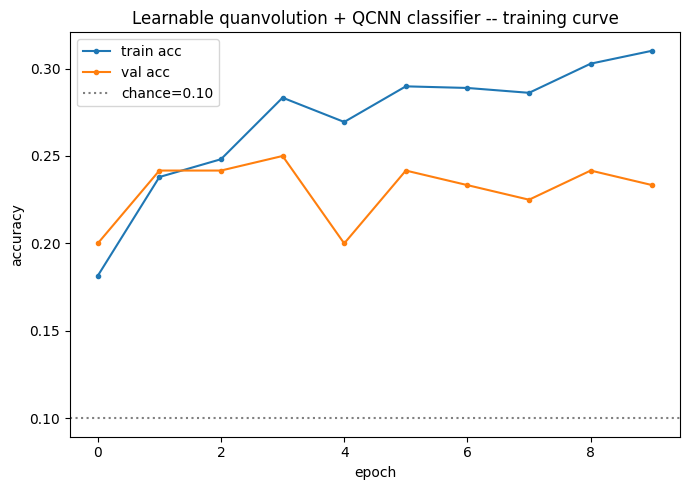

In [11]:
quanv_test_acc = accuracy_score(y_test, quanv_model.predict(X_patches_test))
chance = 1.0 / CONFIG["NUM_CLASSES"]
REFERENCE_CNN_ACC = 0.635   # main notebook, full model, Pi4Angle, SAMPLES_PER_CLASS=500 -- not like-for-like, see note above

print(f"Learnable quanvolution + QCNN classifier -- test accuracy: {quanv_test_acc:.3f}")
print(f"Chance level                                              : {chance:.3f}")
print(f"Classical-CNN pipeline reference (different sample count) : {REFERENCE_CNN_ACC:.3f}")

plt.figure(figsize=(7, 5))
epochs_x = quanv_history["epoch"]
plt.plot(epochs_x, quanv_history["train_acc"], label="train acc", marker="o", markersize=3)
plt.plot(epochs_x, quanv_history["val_acc"], label="val acc", marker="o", markersize=3)
plt.axhline(chance, color="gray", linestyle=":", label=f"chance={chance:.2f}")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Learnable quanvolution + QCNN classifier -- training curve")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Qualitative check -- do the learned channel maps look like they picked up anything?

Visualizes the *raw* (pre-quantum, classical) intensity/edge/texture patch grids for a few test
images, so you can sanity-check the input the quantum channels are actually working with. (The
post-circuit quantum feature maps aren't directly visualizable as an "image" the same way -- each
value is a Z-expectation, not a spatial intensity -- but their classical inputs are, and are the
right first thing to eyeball if accuracy looks off.)


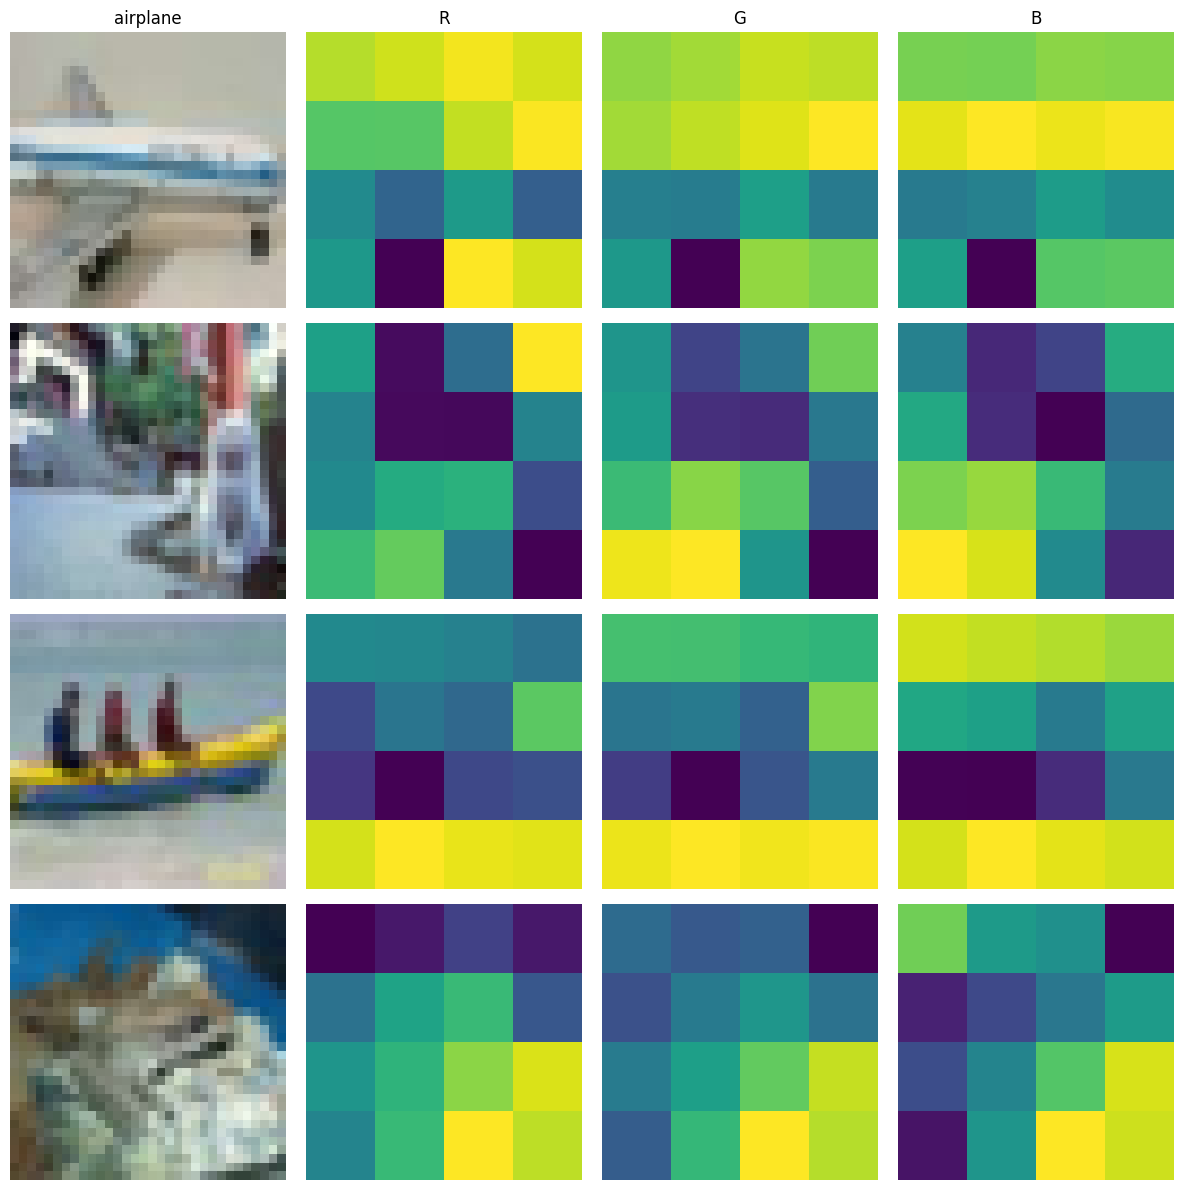

In [12]:
n_show = 4
fig, axes = plt.subplots(n_show, len(CONFIG["QUANV_CHANNELS"]) + 1, figsize=(3 * (len(CONFIG["QUANV_CHANNELS"]) + 1), 3 * n_show))
rng_show = np.random.default_rng(0)
show_idx = rng_show.choice(len(X_test_img), n_show, replace=False)

for row, idx in enumerate(show_idx):
    axes[row, 0].imshow(X_test_img[idx])
    axes[row, 0].set_title(f"{CIFAR10_CLASSES[y_test[idx]]}" if row == 0 else "")
    axes[row, 0].axis("off")
    for ci, name in enumerate(CONFIG["QUANV_CHANNELS"]):
        chan_grid = X_patches_test[idx, :, ci, :].reshape(GRID_Hp, GRID_Wp, -1).mean(axis=-1)
        axes[row, ci + 1].imshow(chan_grid, cmap="viridis")
        if row == 0:
            axes[row, ci + 1].set_title(name)
        axes[row, ci + 1].axis("off")

plt.tight_layout()
plt.show()


## 12. Summary and next steps

- All quanvolution and fusion weights were trained **jointly** with the classifier, via a single
  `qml.AdamOptimizer` over every parameter group -- nothing here is fixed/random, unlike the
  earlier feasibility-scoped proposal.
- Compare `quanv_test_acc` against the classical-CNN pipeline run at the **same**
  `SAMPLES_PER_CLASS` and `EPOCHS` for a fair number (the `REFERENCE_CNN_ACC` above is not that).
- If `QUANV_NUM_LAYERS=2` underperforms `QUANV_NUM_LAYERS=1`, check the embedding dimension the
  fusion stage collapsed down to (`quanv_model.embed_dim`) -- this is the same
  information-starvation failure mode diagnosed in the main notebook's FPN-QCNN section, just one
  level earlier in the pipeline.
- To scale up once the runtime estimate looks acceptable: raise `SAMPLES_PER_CLASS` toward 500,
  raise `EPOCHS`, or set `QUANV_MULTI_BASIS=True` for a richer (but 3x costlier) per-patch readout.
- For a controlled comparison to the earlier fixed-random-weights proposal: rerun with the
  quanvolution channel weights frozen after initialization (skip them in `all_params`/`set_params`
  and the optimizer's parameter list) to isolate how much the *learnability* itself is worth.
